## Section 1 - Import Libraries

In [1]:
import os   #Used for file and folder handling
import cv2   #Used for image processing
import numpy as np   #Used for numerical and array operations
import matplotlib.pyplot as plt   #Used for image visualization
from collections import Counter

Lists are converted into NumPy arrays for efficient processing.

Deep learning frameworks work faster with NumPy arrays compared to Python lists.

## Section 2 - Dataset and save path

In [2]:
DATASET_PATH = "/Users/manish/Documents/Semister 2/7. Project/Aarti Data Droplet/plantVillage dataset/color"

SAVE_PATH = "/Users/manish/Documents/Semister 2/7. Project/Aarti Data Droplet"

os.makedirs(SAVE_PATH, exist_ok=True)
print(f"Dataset path : {DATASET_PATH}")
print(f"Save path : {SAVE_PATH}")


Dataset path : /Users/manish/Documents/Semister 2/7. Project/Aarti Data Droplet/plantVillage dataset/color
Save path : /Users/manish/Documents/Semister 2/7. Project/Aarti Data Droplet


## Section 3 - Exploratory Data Analysis (EDA)

In [3]:
# Read all class folder names
classes = [
    c for c in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, c))
    and not c.startswith(".")
]
classes.sort()

print(f"Total Classes: {len(classes)}")
print()
for c in classes:
    count = len([
        f for f in os.listdir(os.path.join(DATASET_PATH, c))
        if not f.startswith(".")
    ])
    print(f" {count:>5}  {c}")

Total Classes: 38

   630  Apple___Apple_scab
   621  Apple___Black_rot
   275  Apple___Cedar_apple_rust
  1645  Apple___healthy
  1502  Blueberry___healthy
  1052  Cherry_(including_sour)___Powdery_mildew
   854  Cherry_(including_sour)___healthy
   513  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
  1192  Corn_(maize)___Common_rust_
   985  Corn_(maize)___Northern_Leaf_Blight
  1162  Corn_(maize)___healthy
  1180  Grape___Black_rot
  1383  Grape___Esca_(Black_Measles)
  1076  Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
   423  Grape___healthy
  5507  Orange___Haunglongbing_(Citrus_greening)
  2297  Peach___Bacterial_spot
   360  Peach___healthy
   997  Pepper,_bell___Bacterial_spot
  1478  Pepper,_bell___healthy
  1000  Potato___Early_blight
  1000  Potato___Late_blight
   152  Potato___healthy
   371  Raspberry___healthy
  5090  Soybean___healthy
  1835  Squash___Powdery_mildew
  1109  Strawberry___Leaf_scorch
   456  Strawberry___healthy
  2127  Tomato___Bacterial_spot
  1000 

In [4]:
images = []   # store images
labels = []   # store labels

for class_name in classes:
    class_path = os.path.join(DATASET_PATH, class_name)

    for image_name in os.listdir(class_path):
        if image_name.startswith("."):
            continue

        image_path = os.path.join(class_path, image_name)

        # Read image
        image = cv2.imread(image_path)

        # Skip corrupted images
        if image is None:
            continue

        # Convert BGR to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Resize to 224x224 — required for all 3 pretrained models
        image = cv2.resize(image, (224, 224))

        images.append(image)
        labels.append(class_name)

print(f"Total images loaded: {len(images):,}")


Total images loaded: 54,305


In [5]:
images = np.array(images, dtype=np.uint8)
labels = np.array(labels)

print(f"Images shape : {images.shape}")
print(f"Labels shape : {labels.shape}")
print(f"Data type : {images.dtype}")

Images shape : (54305, 224, 224, 3)
Labels shape : (54305,)
Data type : uint8


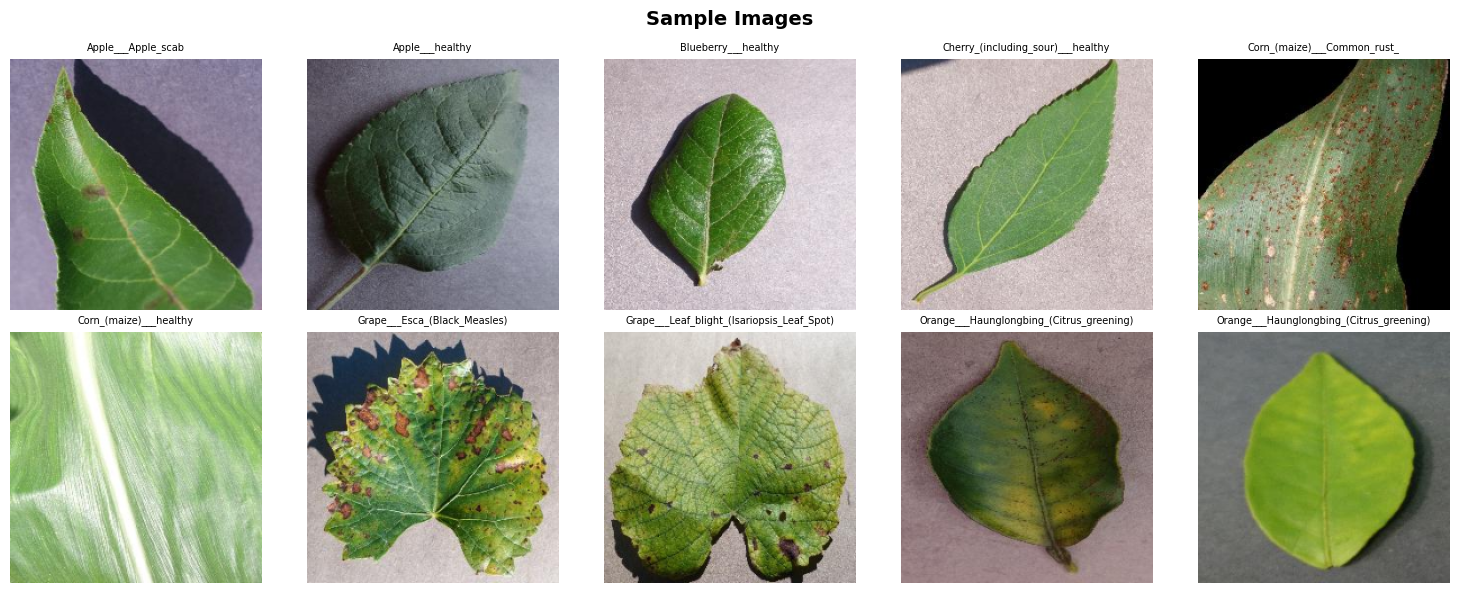

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample Images", fontsize=14, fontweight="bold")

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i * 2000])
    ax.set_title(labels[i * 2000], fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.show()

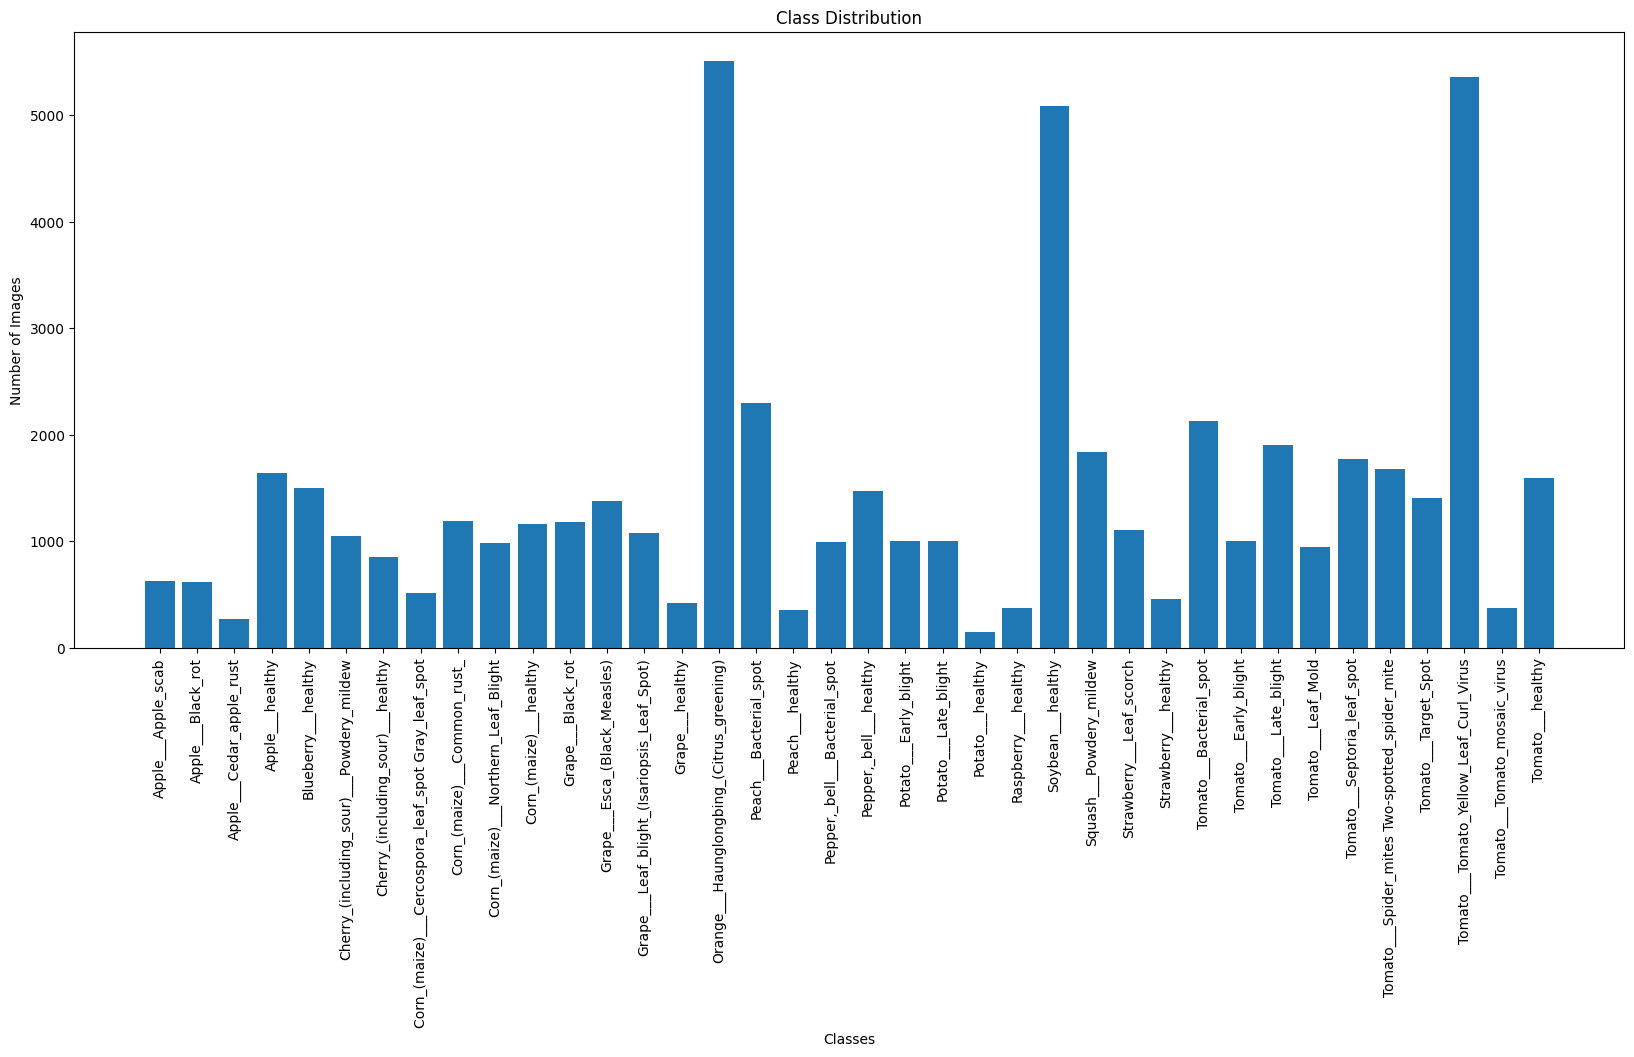

In [7]:
#Count images in every class
class_counts = Counter(labels)

#Store class names
class_names = list(class_counts.keys())

#Store image counts
counts = list(class_counts.values())

plt.figure(figsize=(20,8))   #Create graph
plt.bar(class_names, counts)   #Create bar chart
plt.xticks(rotation=90)   #Rotate class (x-axis) labels
plt.title("Class Distribution")   #Graph title
plt.xlabel("Classes")   #X-axis label
plt.ylabel("Number of Images")   #Y-axis label
plt.show()

## Section 4 - Convert and save data into .npy 

In [ ]:
images_save_path = os.path.join(SAVE_PATH, "images.npy")
labels_save_path = os.path.join(SAVE_PATH, "labels.npy")

np.save(images_save_path, images)
np.save(labels_save_path, labels)

print()
print("Saved")
print(f"images - {images_save_path}")
print(f"labels - {labels_save_path}")


Saving images.npy ...
Saving labels.npy ...

Saved successfully!
  images.npy → /Users/manish/Documents/Semister 2/7. Project/Aarti Data Droplet/images.npy
  labels.npy → /Users/manish/Documents/Semister 2/7. Project/Aarti Data Droplet/labels.npy


In [ ]:
# Reload and check
images_check = np.load(images_save_path)
labels_check = np.load(labels_save_path, allow_pickle=True)

print(f"Images shape : {images_check.shape}")
print(f"Labels shape : {labels_check.shape}")
print(f"Classes : {len(np.unique(labels_check))}")
print()

# Class distribution
unique, counts = np.unique(labels_check, return_counts=True)
print("Images per class:")
for cls, cnt in zip(unique, counts):
    print(f"  {cnt:>5}  {cls}")

Images shape : (54305, 224, 224, 3)
Labels shape : (54305,)
Classes      : 38

Images per class:
    630  Apple___Apple_scab
    621  Apple___Black_rot
    275  Apple___Cedar_apple_rust
   1645  Apple___healthy
   1502  Blueberry___healthy
   1052  Cherry_(including_sour)___Powdery_mildew
    854  Cherry_(including_sour)___healthy
    513  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   1192  Corn_(maize)___Common_rust_
    985  Corn_(maize)___Northern_Leaf_Blight
   1162  Corn_(maize)___healthy
   1180  Grape___Black_rot
   1383  Grape___Esca_(Black_Measles)
   1076  Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
    423  Grape___healthy
   5507  Orange___Haunglongbing_(Citrus_greening)
   2297  Peach___Bacterial_spot
    360  Peach___healthy
    997  Pepper,_bell___Bacterial_spot
   1478  Pepper,_bell___healthy
   1000  Potato___Early_blight
   1000  Potato___Late_blight
    152  Potato___healthy
    371  Raspberry___healthy
   5090  Soybean___healthy
   1835  Squash___Powdery_mild